# 03 - Analisis Exploratorio Final
Graficas curadas que resumen los hallazgos principales del proyecto, 
pensadas para el reporte y README.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Sample_Superstore.csv', encoding='ISO-8859-1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y', errors='coerce')
df['Mes'] = df['Order Date'].dt.month
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Mes
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10


## Descuento vs Ganancia

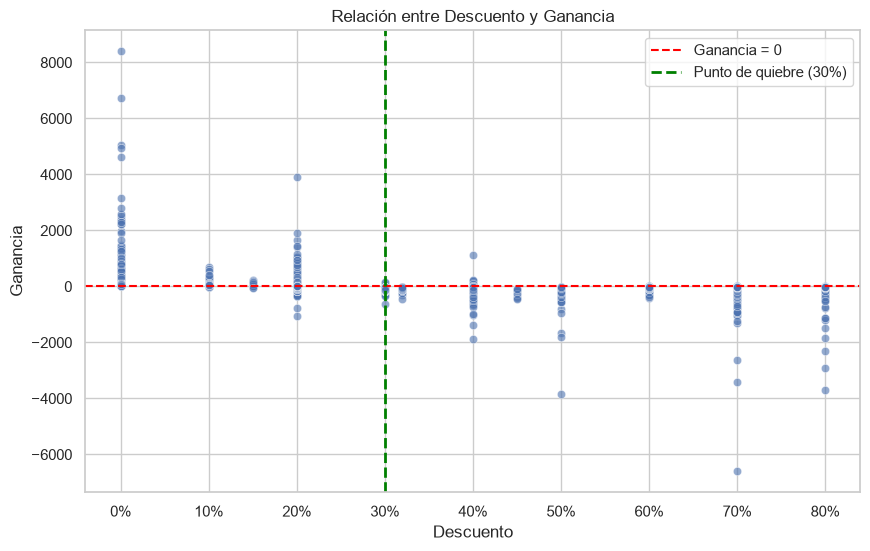

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(10,6))
# Gráfico de dispersión
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)
# Línea horizontal donde la ganancia es 0
plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Ganancia = 0'
)
# Línea vertical en el punto de quiebre (30%)
plt.axvline(
    x=0.30,
    color='green',
    linestyle='--',
    linewidth=2,
    label='Punto de quiebre (30%)'
)
# Título y etiquetas
plt.title('Relación entre Descuento y Ganancia')
plt.xlabel('Descuento')
plt.ylabel('Ganancia')

# Leyenda
plt.legend()
# Formato de porcentaje en el eje X (NUEVA LINEA)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Guarda la imagen para el README
plt.savefig('../images/grafica_descuento_ganancia.png', dpi=150, bbox_inches='tight')
# Mostrar gráfica
plt.show()

## Margen por sub-categoría de Furniture

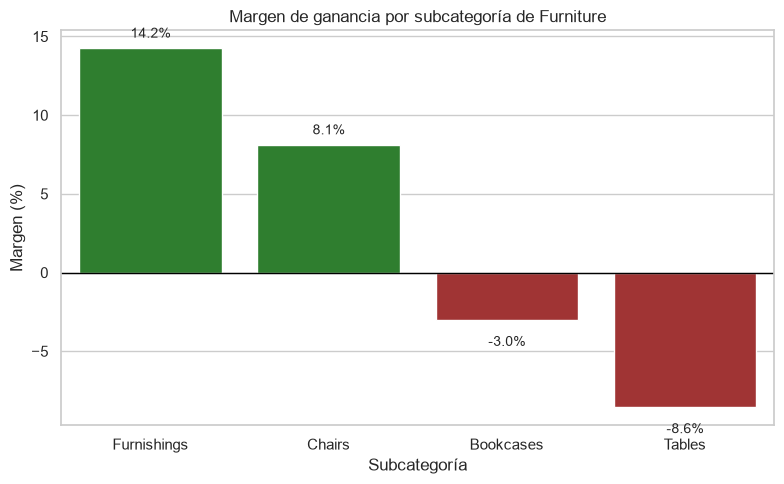

In [30]:
solo_furniture = df[df['Category'] == 'Furniture']

margen_sub = (solo_furniture.groupby('Sub-Category').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
)).sort_values(ascending=False)

margen_sub = margen_sub.rename("Margen (%)")

# Colores: verde si el margen es positivo, rojo si es negativo
colores = [
    "forestgreen" if x >= 0 else "firebrick"
    for x in margen_sub
]

# Crear gráfica
plt.figure(figsize=(8,5))

sns.barplot(
    data=margen_sub.reset_index(),
    x="Sub-Category",
    y="Margen (%)",
    hue="Sub-Category",
    palette=colores,
    legend=False
)

# Línea en el margen cero
plt.axhline(0, color="black", linewidth=1)

# Título y etiquetas
plt.title("Margen de ganancia por subcategoría de Furniture")
plt.xlabel("Subcategoría")
plt.ylabel("Margen (%)")

# Mostrar el porcentaje sobre cada barra
for i, valor in enumerate(margen_sub):
    plt.text(
        i,
        valor + (0.5 if valor >= 0 else -1),
        f"{valor:.1f}%",
        ha="center",
        va="bottom" if valor >= 0 else "top",
        fontsize=10
    )

plt.tight_layout()
plt.savefig('../images/grafica_margen_furniture.png', dpi=150, bbox_inches='tight')
plt.show()

## Ventas y margen por mes

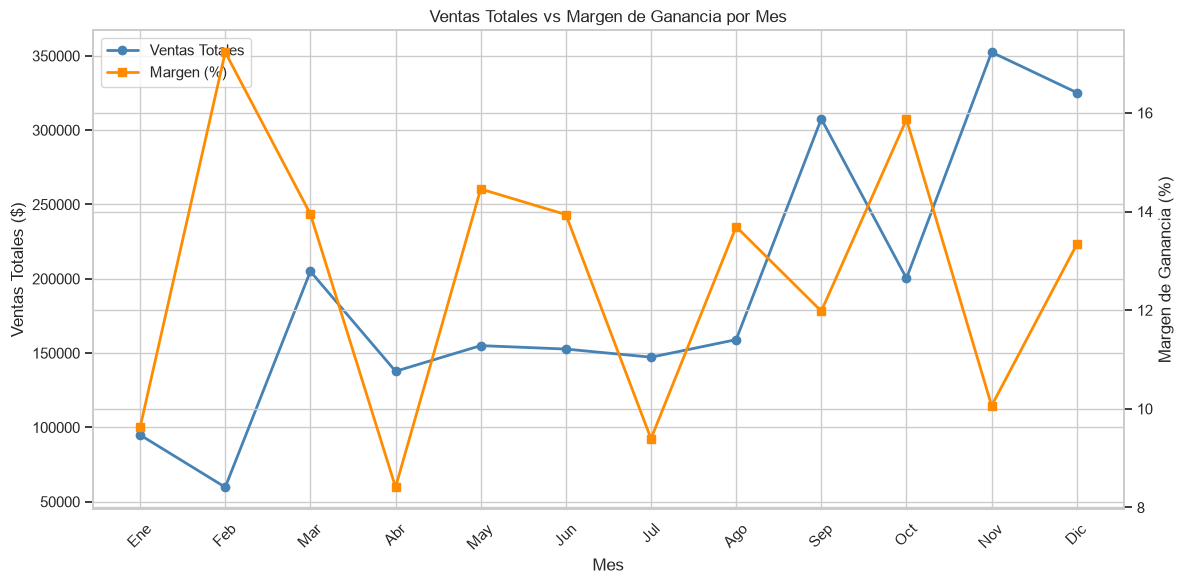

In [39]:
import matplotlib.pyplot as plt

# Ventas totales por mes
ventas_mes = df.groupby('Mes')['Sales'].sum()

# Margen de ganancia por mes
margen_mes = (
    df.groupby('Mes')['Profit'].sum() /
    df.groupby('Mes')['Sales'].sum()
) * 100

ventas_mes = ventas_mes.sort_index()
margen_mes = margen_mes.sort_index()

# Crear gráfico con doble eje
fig, ax1 = plt.subplots(figsize=(12,6))

# Ventas
ax1.plot(
    ventas_mes.index,
    ventas_mes.values,
    marker='o',
    linewidth=2,
    color='steelblue',
    label='Ventas Totales'
)
ax1.set_xlabel('Mes')
ax1.set_ylabel('Ventas Totales ($)')

# Margen
ax2 = ax1.twinx()
ax2.plot(
    margen_mes.index,
    margen_mes.values,
    marker='s',
    linewidth=2,
    color='darkorange',
    label='Margen (%)'
)
ax2.set_ylabel('Margen de Ganancia (%)')

# Cambiar números por nombres de meses en el eje X
nombres_meses = [
    'Ene', 'Feb', 'Mar', 'Abr',
    'May', 'Jun', 'Jul', 'Ago',
    'Sep', 'Oct', 'Nov', 'Dic'
]

# Ajustes visuales
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(nombres_meses, rotation=45)

# NUEVO: combina las leyendas de ambos ejes
lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2, loc='upper left')

plt.title('Ventas Totales vs Margen de Ganancia por Mes')
plt.tight_layout()

# NUEVO: guarda la imagen para el README
plt.savefig('../images/grafica_estacionalidad.png', dpi=150, bbox_inches='tight')

plt.show()

## Margen de ganancia por región

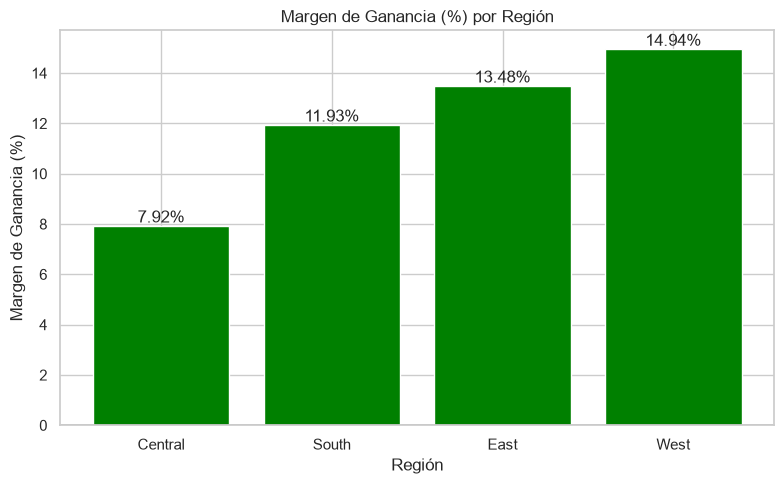

In [40]:
import matplotlib.pyplot as plt


# Calcular margen por región
margen_region = (
    df.groupby('Region')['Profit'].sum() /
    df.groupby('Region')['Sales'].sum()
) * 100

# Ordenar regiones
margen_region = margen_region.sort_values()

# Colores según el signo del margen
colores = [
    'red' if valor < 0 else 'green'
    for valor in margen_region.values
]

# Crear gráfica
plt.figure(figsize=(8,5))

barras = plt.bar(
    margen_region.index,
    margen_region.values,
    color=colores
)

# Agregar valores encima de las barras
for barra, valor in zip(barras, margen_region.values):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor,
        f'{valor:.2f}%',
        ha='center',
        va='bottom' if valor >= 0 else 'top'
    )

# Línea de referencia en 0%
plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.title(
    'Margen de Ganancia (%) por Región'
)

plt.xlabel('Región')
plt.ylabel('Margen de Ganancia (%)')

plt.tight_layout()
plt.show()

## Top estados con problemas de rentabilidad

In [43]:
import matplotlib.pyplot as plt

# Calcular métricas por estado
estado_resumen = df.groupby('State').agg(
    Ventas=('Sales', 'sum'),
    Ganancia=('Profit', 'sum'),
    Transacciones=('Order ID', 'count')
)

# Calcular margen %
estado_resumen['Margen (%)'] = (
    estado_resumen['Ganancia'] /
    estado_resumen['Ventas']
) * 100

# Filtrar estados con suficiente volumen
estados_confiables = estado_resumen[
    estado_resumen['Transacciones'] > 50
]

# Obtener los 10 estados con peor margen
peores_estados = (
    estados_confiables
    .sort_values('Margen (%)')
    .head(10)
)

print(peores_estados)

                     Ventas    Ganancia  Transacciones  Margen (%)
State                                                             
Ohio             78258.1360 -16971.3766            469  -21.686405
Colorado         32108.1180  -6527.8579            182  -20.330864
Tennessee        30661.8730  -5341.6936            183  -17.421289
Illinois         80166.1010 -12607.8870            492  -15.727205
Texas           170188.0458 -25729.3563            985  -15.118192
North Carolina   55603.1640  -7490.9122            249  -13.472097
Pennsylvania    116511.9140 -15559.9603            587  -13.354823
Arizona          35282.0010  -3427.9246            224   -9.715789
Oregon           17431.1500  -1190.4705            124   -6.829558
Florida          89473.7080  -3399.3017            383   -3.799219


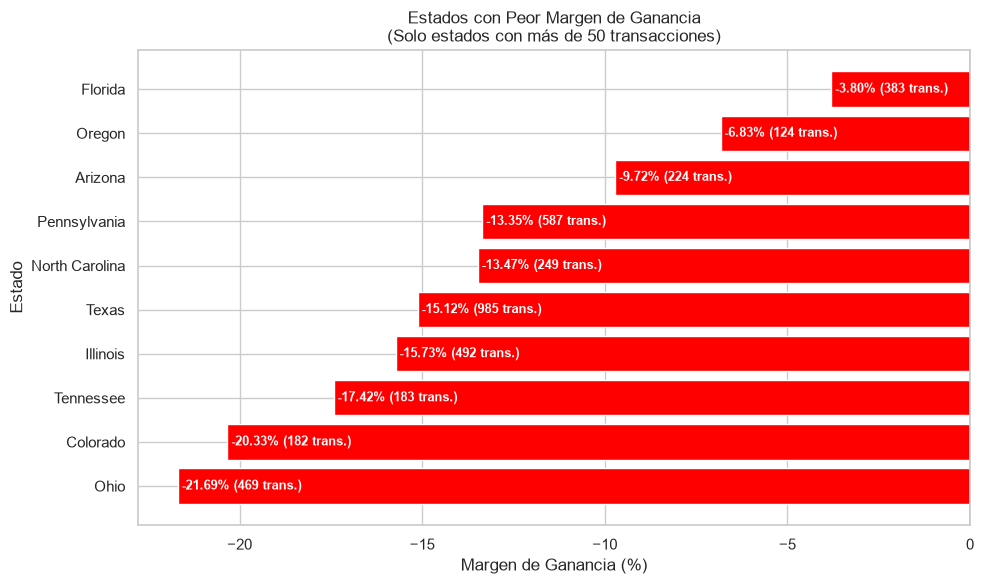

In [66]:
# Colores según margen
colores = [
    'red' if valor < 0 else 'green'
    for valor in peores_estados['Margen (%)']
]

plt.figure(figsize=(10,6))
barras = plt.barh(
    peores_estados.index,
    peores_estados['Margen (%)'],
    color=colores
)

# Etiquetas con margen y transacciones
for barra, margen, trans in zip(
    barras,
    peores_estados['Margen (%)'],
    peores_estados['Transacciones']
):
    plt.text(
        barra.get_width() + 0.1,
        barra.get_y() + barra.get_height()/2,
        f'{margen:.2f}% ({trans} trans.)',
        va='center',
        ha='left',
        color='white',
        fontweight='bold',
        fontsize=9
    )

# Línea de referencia
plt.axvline(0, color='black', linewidth=1)

plt.title(
    'Estados con Peor Margen de Ganancia\n'
    '(Solo estados con más de 50 transacciones)'
)
plt.xlabel('Margen de Ganancia (%)')
plt.ylabel('Estado')


plt.tight_layout()
plt.savefig('../images/grafica_estados_problematicos.png', dpi=150, bbox_inches='tight')
plt.show()